# Data Visualization

## Libraries

In [1]:
import pandas as pd


In [2]:
# %pip install -U kaleido

## Loading

In [3]:

df = pd.read_excel(r"C:\Users\joana\OneDrive\Documenti\03.AIDA\1.Lezioni\1.Big Data Processing and Data Engineering\13.Project\4.DataVisualization\OUTPUT_Unione_Aida_Registro.xlsx")
print(df.head())

   codice_fiscale                                ragione_sociale codice_ateco  \
0      2892000429                              TERZA BASE S.R.L.       107110   
1     11331520962                                FOOLFARM S.P.A.       621000   
2     15991751007                                 WETACOO S.R.L.       621000   
3      4457480160                              BCC STUDIO S.R.L.       621000   
4      7205120483  MEETALPHA SOCIETA' A RESPONSABILITA' LIMITATA       621000   

       comune provincia    regione                      forma_giuridica  \
0  SENIGALLIA        AN     MARCHE  SOCIETA' A RESPONSABILITA' LIMITATA   
1      MILANO        MI  LOMBARDIA                  SOCIETA' PER AZIONI   
2        ROMA        RM      LAZIO  SOCIETA' A RESPONSABILITA' LIMITATA   
3     BERGAMO        BG  LOMBARDIA  SOCIETA' A RESPONSABILITA' LIMITATA   
4     FIRENZE        FI    TOSCANA  SOCIETA' A RESPONSABILITA' LIMITATA   

  ateco_sezione_cod                       ateco_sezione_desc  

## Geografia per macro settore

In [2]:
import json
import textwrap

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ── AUTOSTRADE PRINCIPALI (per l'overlay sulla mappa) ────────────────────────
# Tracciati semplificati delle autostrade/superstrade italiane (fonte: Natural
# Earth 1:10m roads, filtrati sull'Italia), incorporati qui per non dipendere
# da una connessione internet quando esegui lo script. 103 segmenti, ~2.700 punti.
_AUTOSTRADE_COORDS = json.loads(r'''[[[7.684,44.975],[7.615,45.021],[7.581,45.04],[7.563,45.047],[7.535,45.057]],[[7.113,45.144],[7.221,45.148]],[[9.051,45.519],[9.054,45.51],[9.055,45.501],[9.054,45.492],[9.043,45.452],[9.043,45.448],[9.043,45.444],[9.044,45.439],[9.045,45.435],[9.047,45.43],[9.05,45.426],[9.054,45.422],[9.058,45.42],[9.086,45.406],[9.141,45.385],[9.159,45.381],[9.177,45.378],[9.204,45.377],[9.246,45.372],[9.25,45.372],[9.254,45.373],[9.257,45.375],[9.259,45.378],[9.26,45.382],[9.267,45.471],[9.266,45.474],[9.265,45.478],[9.263,45.481],[9.248,45.5],[9.244,45.51],[9.245,45.519],[9.249,45.525],[9.255,45.53],[9.281,45.545],[9.353,45.574]],[[10.772,45.463],[10.849,45.447],[10.857,45.444],[10.867,45.44],[10.875,45.435],[10.881,45.428],[10.883,45.423],[10.884,45.419],[10.885,45.414],[10.885,45.409],[10.884,45.404],[10.878,45.388]],[[10.78,45.461],[10.735,45.44],[10.723,45.437],[10.71,45.436],[10.697,45.436],[10.648,45.445],[10.636,45.446],[10.581,45.445],[10.556,45.448],[10.506,45.465],[10.481,45.47],[10.423,45.479],[10.323,45.509],[10.305,45.513],[10.287,45.514],[10.269,45.511],[10.258,45.508]],[[10.892,44.659],[10.881,44.666],[10.869,44.672],[10.432,44.797],[10.384,44.817],[10.306,44.858],[10.285,44.867],[10.274,44.871],[10.249,44.876],[10.077,44.891],[10.054,44.895],[10.019,44.906],[9.996,44.915],[9.822,45.013],[9.658,45.139],[9.26,45.379]],[[8.434,44.298],[8.432,44.303],[8.427,44.306],[8.423,44.309],[8.41,44.314],[8.304,44.337],[8.231,44.345],[8.176,44.346],[8.167,44.347],[8.158,44.349],[8.149,44.353],[8.141,44.357],[8.116,44.375],[8.107,44.38],[8.097,44.383],[8.088,44.384],[8.078,44.384],[8.068,44.384],[8.059,44.382],[8.032,44.374],[8.023,44.373],[8.013,44.372],[8.004,44.373],[7.995,44.375],[7.985,44.378],[7.981,44.38],[7.969,44.388],[7.965,44.39],[7.961,44.391],[7.892,44.401],[7.868,44.408],[7.863,44.41],[7.859,44.412],[7.856,44.415],[7.849,44.422],[7.838,44.435],[7.819,44.467],[7.8,44.503],[7.791,44.522],[7.788,44.532],[7.783,44.551],[7.781,44.555],[7.778,44.56],[7.775,44.564],[7.763,44.574],[7.761,44.578],[7.759,44.582],[7.758,44.586],[7.757,44.59],[7.757,44.6],[7.758,44.608],[7.76,44.617],[7.773,44.644],[7.776,44.653],[7.776,44.663],[7.773,44.673],[7.762,44.701],[7.759,44.71],[7.757,44.72],[7.756,44.73],[7.756,44.74],[7.763,44.817],[7.763,44.837],[7.76,44.856],[7.756,44.876],[7.75,44.895],[7.739,44.918],[7.723,44.939],[7.704,44.958],[7.684,44.975]],[[8.926,44.457],[8.931,44.45],[8.938,44.443],[8.946,44.438],[8.954,44.434],[8.995,44.421],[9.188,44.383],[9.332,44.335],[9.503,44.251],[9.528,44.243],[9.553,44.238],[9.709,44.225],[9.801,44.209],[9.845,44.199],[9.866,44.19],[9.885,44.178],[9.894,44.17],[9.923,44.137],[9.939,44.121],[9.947,44.113],[9.985,44.089],[10.026,44.069],[10.152,44.021],[10.192,44.002],[10.211,43.991],[10.228,43.979],[10.232,43.976],[10.236,43.972],[10.24,43.968],[10.242,43.963],[10.249,43.945],[10.257,43.927],[10.265,43.913],[10.294,43.875]],[[8.729,44.442],[8.718,44.441],[8.709,44.439],[8.7,44.435],[8.681,44.424],[8.67,44.42],[8.625,44.409],[8.614,44.405],[8.603,44.4],[8.549,44.363],[8.473,44.324],[8.451,44.311],[8.441,44.303],[8.433,44.296],[8.398,44.254],[8.39,44.247],[8.381,44.242],[8.351,44.229],[8.32,44.211],[8.255,44.182],[8.253,44.18],[8.216,44.133],[8.168,44.087],[8.162,44.08],[8.115,43.989],[8.11,43.982],[8.105,43.976],[8.091,43.962],[8.076,43.95],[8.06,43.939],[8.042,43.929],[8.006,43.912],[7.711,43.828],[7.64,43.818]],[[9.102,45.394],[9.091,45.379],[9.087,45.372],[9.083,45.363],[9.068,45.322],[9.024,45.23],[9.023,45.227],[9.02,45.211],[9.02,45.192],[9.018,45.178],[9.014,45.159],[9.008,45.14],[9.0,45.122],[8.982,45.091],[8.853,44.928],[8.817,44.868],[8.802,44.832],[8.796,44.813],[8.796,44.794],[8.803,44.775],[8.809,44.767],[8.873,44.706],[8.959,44.636],[8.964,44.629],[8.969,44.622],[8.972,44.614],[8.972,44.605],[8.97,44.595],[8.931,44.505],[8.926,44.486],[8.925,44.466],[8.925,44.464],[8.926,44.457]],[[8.927,44.452],[8.904,44.451],[8.88,44.449],[8.834,44.439],[8.808,44.436],[8.729,44.434]],[[9.012,46.222],[9.01,46.214],[9.007,46.206],[9.004,46.199],[8.999,46.193],[8.993,46.188],[8.975,46.177],[8.966,46.17],[8.958,46.163],[8.951,46.155],[8.945,46.146],[8.94,46.136],[8.936,46.126],[8.931,46.104],[8.926,46.065],[8.927,46.026],[8.935,45.987],[8.953,45.952],[8.958,45.944],[8.965,45.937],[8.972,45.931],[8.981,45.923],[8.987,45.919],[8.993,45.916],[8.994,45.915],[8.995,45.913],[8.996,45.91],[8.997,45.908],[8.998,45.905],[8.998,45.896],[8.996,45.887],[8.991,45.88],[8.984,45.876],[8.967,45.874],[8.965,45.873],[8.963,45.871],[8.963,45.87],[8.965,45.868],[8.968,45.864],[8.97,45.863],[8.972,45.861],[8.977,45.859],[8.986,45.856],[9.021,45.85],[9.025,45.849],[9.029,45.847],[9.033,45.845],[9.035,45.842],[9.036,45.838],[9.037,45.833],[9.038,45.829],[9.047,45.801],[9.048,45.792],[9.049,45.78],[9.049,45.777],[9.045,45.767],[9.044,45.764],[9.023,45.731],[9.018,45.721],[9.01,45.703],[9.005,45.684],[8.999,45.654],[8.999,45.651],[9.041,45.516]],[[6.709,45.078],[6.715,45.066],[6.73,45.06],[6.743,45.061],[6.763,45.056],[6.773,45.055],[6.783,45.054],[6.792,45.055],[6.808,45.058],[6.847,45.069],[6.867,45.078],[6.869,45.08],[6.875,45.085],[6.877,45.088],[6.879,45.092],[6.89,45.118],[6.894,45.127],[6.9,45.135],[6.914,45.149],[6.93,45.16],[6.947,45.168],[6.966,45.172],[6.976,45.172],[6.985,45.171],[7.004,45.168],[7.06,45.15],[7.077,45.147],[7.113,45.144]],[[7.221,45.148],[7.342,45.139],[7.359,45.135],[7.375,45.127],[7.422,45.091],[7.439,45.081],[7.456,45.074],[7.474,45.068],[7.535,45.057]],[[9.044,45.518],[9.027,45.513],[9.011,45.511],[8.954,45.51],[8.927,45.506],[8.794,45.476],[8.74,45.468],[8.712,45.467],[8.551,45.482],[8.404,45.477],[8.273,45.464],[8.235,45.456],[8.195,45.444],[8.16,45.429],[8.152,45.425],[8.118,45.399],[7.943,45.243],[7.926,45.231],[7.907,45.222],[7.897,45.219],[7.857,45.212],[7.81,45.201],[7.746,45.178],[7.722,45.164]],[[7.535,45.057],[7.535,45.066],[7.535,45.071],[7.535,45.074],[7.536,45.075],[7.557,45.091],[7.607,45.118],[7.725,45.164]],[[7.642,43.819],[7.523,43.824],[7.484,43.821],[7.465,43.817],[7.456,43.814],[7.435,43.805],[7.389,43.772],[7.373,43.763],[7.354,43.755],[7.344,43.752],[7.229,43.728],[7.199,43.717],[7.195,43.715],[7.061,43.625],[6.957,43.579],[6.92,43.555],[6.91,43.55],[6.899,43.546],[6.888,43.544],[6.877,43.544],[6.816,43.55],[6.792,43.55],[6.768,43.542],[6.753,43.532],[6.742,43.52],[6.723,43.492],[6.689,43.464],[6.646,43.457],[6.557,43.463],[6.533,43.463],[6.521,43.462],[6.509,43.46],[6.499,43.457],[6.489,43.453],[6.415,43.411],[6.395,43.404],[6.377,43.399],[6.338,43.394],[6.252,43.392],[6.165,43.398],[5.587,43.477],[5.558,43.484],[5.483,43.507],[5.465,43.511],[5.456,43.511],[5.446,43.511],[5.436,43.511],[5.426,43.509],[5.416,43.506],[5.378,43.494],[5.369,43.492],[5.359,43.492],[5.34,43.494],[5.33,43.496],[5.294,43.51],[5.252,43.534],[5.222,43.556],[5.167,43.605],[5.151,43.616],[5.133,43.625],[5.128,43.626],[4.986,43.647],[4.968,43.648],[4.858,43.638],[4.806,43.638],[4.754,43.643],[4.704,43.654],[4.654,43.671],[4.602,43.696],[4.584,43.702],[4.498,43.719],[4.479,43.725],[4.46,43.732],[4.37,43.778]],[[6.608,45.179],[6.649,45.174],[6.669,45.168],[6.685,45.155],[6.694,45.138],[6.702,45.097],[6.709,45.078]],[[11.373,47.233],[11.381,47.228],[11.385,47.222],[11.386,47.214],[11.384,47.195],[11.384,47.186],[11.387,47.178],[11.392,47.169],[11.4,47.158],[11.455,47.1],[11.461,47.093],[11.494,47.029],[11.497,47.02],[11.497,47.011],[11.495,47.001],[11.491,46.994],[11.486,46.988],[11.475,46.976],[11.468,46.968],[11.462,46.959],[11.458,46.949],[11.455,46.938]],[[11.461,46.944],[11.449,46.94],[11.438,46.935],[11.427,46.927],[11.421,46.917],[11.421,46.909],[11.424,46.901],[11.429,46.894],[11.435,46.888],[11.456,46.872],[11.48,46.859],[11.582,46.82],[11.599,46.812],[11.615,46.801],[11.63,46.788],[11.643,46.774],[11.653,46.757],[11.657,46.749],[11.661,46.739],[11.663,46.73],[11.664,46.72],[11.664,46.706],[11.664,46.701],[11.661,46.691],[11.658,46.681],[11.654,46.672],[11.649,46.664],[11.643,46.657],[11.636,46.651],[11.628,46.645],[11.575,46.619],[11.568,46.614],[11.561,46.607],[11.555,46.6],[11.551,46.592],[11.537,46.556],[11.53,46.543],[11.522,46.532],[11.51,46.522],[11.496,46.517],[11.482,46.515],[11.466,46.516],[11.402,46.526],[11.385,46.525],[11.37,46.522],[11.355,46.515],[11.342,46.505],[11.327,46.492],[11.314,46.476],[11.291,46.443],[11.273,46.411],[11.242,46.334],[11.23,46.313],[11.216,46.296],[11.208,46.29],[11.2,46.286],[11.163,46.269],[11.154,46.264],[11.145,46.257],[11.133,46.247],[11.122,46.234],[11.115,46.22],[11.11,46.204],[11.108,46.187],[11.108,46.169],[11.112,46.133],[11.117,46.113],[11.13,46.08]],[[13.291,45.881],[13.28,45.922],[13.272,45.943],[13.218,46.046],[13.209,46.068],[13.196,46.108],[13.187,46.124],[13.176,46.138],[13.162,46.151],[13.115,46.187],[13.108,46.194],[13.103,46.202],[13.101,46.208],[13.099,46.214],[13.099,46.252],[13.098,46.261],[13.093,46.276],[13.076,46.321],[13.073,46.335],[13.072,46.348],[13.076,46.36],[13.084,46.372],[13.102,46.384],[13.122,46.392],[13.144,46.396],[13.165,46.397],[13.237,46.39],[13.261,46.39],[13.278,46.391],[13.295,46.396],[13.309,46.406],[13.318,46.421],[13.32,46.435],[13.318,46.478],[13.32,46.492],[13.325,46.504],[13.333,46.514],[13.346,46.519],[13.354,46.52],[13.363,46.519],[13.38,46.516],[13.442,46.498],[13.464,46.495],[13.492,46.495],[13.52,46.496],[13.548,46.5],[13.587,46.509],[13.599,46.514],[13.611,46.519],[13.663,46.554],[13.682,46.563],[13.704,46.568],[13.727,46.57],[13.795,46.568],[13.806,46.568],[13.817,46.57],[13.827,46.572],[13.845,46.579],[13.89,46.6],[13.908,46.605],[13.928,46.607]],[[13.314,45.883],[13.389,45.869],[13.548,45.827],[13.587,45.82],[13.623,45.81],[13.631,45.806],[13.697,45.768],[13.802,45.696],[13.816,45.683],[13.829,45.667],[13.836,45.66],[13.845,45.655],[13.959,45.611]],[[10.874,45.391],[10.909,45.388],[10.995,45.39],[11.014,45.392],[11.033,45.396],[11.042,45.4],[11.05,45.404],[11.066,45.415],[11.074,45.42],[11.083,45.422],[11.092,45.423],[11.1,45.423],[11.181,45.413],[11.254,45.409],[11.291,45.413],[11.326,45.423],[11.42,45.472],[11.471,45.49],[11.515,45.514],[11.541,45.521],[11.568,45.522],[11.594,45.517],[11.874,45.431],[11.929,45.42],[11.982,45.415],[11.995,45.415],[12.009,45.417],[12.118,45.447],[12.134,45.454],[12.239,45.52],[12.271,45.536],[12.318,45.555]],[[12.318,45.555],[12.468,45.611],[12.716,45.746],[12.782,45.771],[13.227,45.854],[13.252,45.862],[13.297,45.885],[13.303,45.887],[13.315,45.89]],[[10.299,43.879],[10.339,43.88],[10.379,43.877],[10.533,43.844],[10.652,43.828],[10.67,43.827],[10.688,43.829],[10.727,43.839],[10.873,43.899],[10.91,43.911],[10.929,43.915],[10.948,43.917],[10.967,43.917],[10.995,43.914],[11.005,43.912],[11.013,43.909],[11.022,43.904],[11.03,43.898],[11.034,43.895],[11.06,43.867],[11.068,43.859],[11.092,43.844],[11.118,43.833],[11.145,43.827],[11.174,43.826]],[[12.649,42.153],[12.649,42.164],[12.648,42.168],[12.647,42.173],[12.645,42.179],[12.643,42.184],[12.639,42.188],[12.636,42.192],[12.62,42.206],[12.533,42.258],[12.516,42.271],[12.501,42.284],[12.494,42.293],[12.489,42.302],[12.484,42.311],[12.482,42.322],[12.479,42.367],[12.476,42.382],[12.469,42.394],[12.459,42.404],[12.424,42.428],[12.414,42.438],[12.408,42.45]],[[12.412,42.446],[12.411,42.449],[12.407,42.455],[12.405,42.458],[12.403,42.458],[12.401,42.459],[12.399,42.459],[12.398,42.46],[12.397,42.465],[12.395,42.469],[12.39,42.476],[12.385,42.481],[12.379,42.486],[12.372,42.489],[12.324,42.505],[12.309,42.512],[12.294,42.524],[12.282,42.539],[12.274,42.556],[12.269,42.574],[12.258,42.63],[12.252,42.647],[12.24,42.665],[12.226,42.681],[12.209,42.694],[12.191,42.705],[12.172,42.715],[12.111,42.736],[12.097,42.744],[12.083,42.753],[12.071,42.764],[12.062,42.778],[12.053,42.793],[12.029,42.852],[12.023,42.862],[12.017,42.872],[11.973,42.925],[11.89,43.076],[11.887,43.085],[11.884,43.095],[11.883,43.12],[11.882,43.125],[11.879,43.133],[11.875,43.14],[11.853,43.168],[11.785,43.242],[11.765,43.272],[11.753,43.307],[11.752,43.326],[11.753,43.344],[11.763,43.414],[11.762,43.43],[11.76,43.446],[11.753,43.46],[11.743,43.471],[11.73,43.479],[11.716,43.485],[11.682,43.492],[11.668,43.497],[11.651,43.506],[11.636,43.518],[11.583,43.572],[11.505,43.637],[11.499,43.644],[11.494,43.651],[11.493,43.655],[11.49,43.664],[11.489,43.669],[11.487,43.673],[11.484,43.677],[11.478,43.685],[11.471,43.691],[11.463,43.697],[11.447,43.708],[11.43,43.717],[11.421,43.72],[11.411,43.723],[11.391,43.728],[11.371,43.73],[11.352,43.731],[11.314,43.729],[11.295,43.725],[11.275,43.721],[11.265,43.719],[11.255,43.719],[11.245,43.721],[11.236,43.725],[11.219,43.737],[11.204,43.747],[11.198,43.754],[11.192,43.76],[11.186,43.768],[11.183,43.776],[11.181,43.785],[11.178,43.803],[11.177,43.832]],[[11.174,43.826],[11.173,43.848],[11.176,43.869],[11.183,43.89],[11.211,43.951],[11.219,43.972],[11.224,43.994],[11.226,44.044],[11.2,44.191],[11.198,44.216],[11.198,44.241],[11.199,44.25],[11.2,44.259],[11.204,44.267],[11.208,44.275],[11.213,44.281],[11.236,44.3],[11.241,44.306],[11.246,44.313],[11.251,44.319],[11.258,44.334],[11.264,44.349],[11.273,44.382],[11.276,44.399],[11.277,44.417],[11.277,44.435],[11.275,44.452],[11.272,44.465],[11.267,44.478],[11.259,44.489],[11.249,44.499]],[[11.962,45.415],[11.959,45.406],[11.956,45.397],[11.951,45.389],[11.946,45.381],[11.94,45.373],[11.934,45.366],[11.926,45.36],[11.917,45.356],[11.874,45.345],[11.84,45.333],[11.831,45.328],[11.824,45.322],[11.818,45.315],[11.812,45.307],[11.802,45.291],[11.794,45.273],[11.789,45.255],[11.786,45.236],[11.786,45.215],[11.79,45.196],[11.803,45.157],[11.807,45.139],[11.808,45.122],[11.804,45.104],[11.795,45.089],[11.788,45.081],[11.622,44.96],[11.585,44.927],[11.578,44.919],[11.572,44.911],[11.568,44.902],[11.563,44.885],[11.561,44.869],[11.562,44.835],[11.56,44.814],[11.556,44.794],[11.548,44.775],[11.538,44.756],[11.524,44.739],[11.462,44.674],[11.408,44.596],[11.386,44.554],[11.377,44.531]],[[14.279,41.089],[14.287,41.084],[14.292,41.078],[14.296,41.069],[14.318,40.983],[14.322,40.955],[14.324,40.926],[14.322,40.88],[14.321,40.869],[14.321,40.866],[14.321,40.863],[14.323,40.859],[14.325,40.856],[14.362,40.819],[14.377,40.807],[14.436,40.77],[14.548,40.72],[14.596,40.71],[14.638,40.707],[14.763,40.707],[14.826,40.7]],[[14.822,40.7],[14.85,40.698],[14.896,40.69],[14.91,40.686],[14.916,40.682],[14.918,40.681],[14.919,40.679],[14.927,40.665],[14.93,40.662],[14.936,40.655],[14.944,40.647],[14.97,40.628],[14.977,40.624],[14.985,40.621],[14.993,40.62],[15.14,40.607],[15.17,40.607],[15.199,40.61],[15.236,40.62],[15.256,40.623],[15.265,40.623],[15.28,40.622],[15.306,40.619],[15.388,40.598]],[[15.388,40.598],[15.392,40.595],[15.396,40.592],[15.399,40.588],[15.402,40.584],[15.406,40.576],[15.414,40.557],[15.415,40.556],[15.459,40.539],[15.504,40.527],[15.523,40.517],[15.537,40.503],[15.547,40.486],[15.571,40.428],[15.577,40.417],[15.592,40.397],[15.624,40.361],[15.631,40.351],[15.637,40.342],[15.642,40.332],[15.646,40.322],[15.663,40.257],[15.667,40.248],[15.672,40.238],[15.677,40.23],[15.69,40.212],[15.72,40.181],[15.771,40.14],[15.92,40.043],[15.936,40.029],[15.948,40.011],[15.953,39.998],[15.97,39.928],[15.974,39.918],[15.984,39.903],[15.997,39.892],[16.013,39.883],[16.03,39.878],[16.039,39.877],[16.145,39.876],[16.182,39.872],[16.2,39.868],[16.216,39.862],[16.23,39.853],[16.24,39.841],[16.244,39.824],[16.244,39.811],[16.237,39.771],[16.238,39.758],[16.242,39.746],[16.25,39.737],[16.262,39.73]],[[16.262,39.73],[16.254,39.71],[16.233,39.673],[16.225,39.653],[16.223,39.632],[16.227,39.611],[16.234,39.591],[16.239,39.57],[16.239,39.56],[16.238,39.551],[16.235,39.542],[16.229,39.535],[16.21,39.517],[16.204,39.51],[16.199,39.503],[16.197,39.494],[16.197,39.486],[16.198,39.477],[16.201,39.471],[16.204,39.466],[16.209,39.462],[16.221,39.452],[16.226,39.447],[16.231,39.44],[16.243,39.423],[16.248,39.417],[16.249,39.415],[16.25,39.413],[16.25,39.411],[16.25,39.409],[16.249,39.394],[16.248,39.39],[16.246,39.385],[16.243,39.378],[16.229,39.358],[16.223,39.343],[16.222,39.328],[16.226,39.313],[16.233,39.299],[16.242,39.288],[16.296,39.242],[16.305,39.23],[16.313,39.218],[16.316,39.21],[16.319,39.202],[16.321,39.194],[16.322,39.185],[16.323,39.174],[16.321,39.164],[16.317,39.154],[16.312,39.144],[16.296,39.127],[16.278,39.114],[16.199,39.075],[16.182,39.063],[16.167,39.048],[16.159,39.036],[16.154,39.023],[16.153,39.009],[16.156,38.995],[16.164,38.983],[16.174,38.972],[16.186,38.963],[16.205,38.953],[16.249,38.936],[16.256,38.932],[16.269,38.921],[16.281,38.908],[16.29,38.893],[16.297,38.877]],[[16.296,38.877],[16.275,38.842],[16.216,38.785],[16.189,38.754],[16.179,38.738],[16.171,38.72],[16.166,38.702],[16.156,38.636],[16.152,38.62],[16.144,38.603],[16.132,38.588],[16.118,38.575],[16.041,38.52],[15.97,38.453],[15.829,38.292],[15.806,38.272],[15.793,38.263],[15.779,38.255],[15.765,38.248],[15.688,38.221]],[[14.282,41.089],[14.262,41.101],[14.253,41.107],[14.244,41.115],[14.238,41.123],[14.235,41.133],[14.232,41.142],[14.229,41.151],[14.226,41.155],[14.222,41.158],[14.217,41.16],[14.148,41.189],[14.133,41.198],[14.118,41.209],[14.112,41.215],[14.106,41.221],[14.101,41.228],[14.097,41.235],[14.095,41.243],[14.093,41.251],[14.093,41.311],[14.093,41.32],[14.091,41.329],[14.088,41.338],[14.082,41.346],[14.075,41.352],[14.036,41.375],[14.012,41.386],[13.864,41.437],[13.852,41.44],[13.84,41.441],[13.803,41.444],[13.785,41.449],[13.767,41.456],[13.699,41.497],[13.688,41.502],[13.676,41.505],[13.638,41.509],[13.627,41.512],[13.615,41.516],[13.585,41.536],[13.575,41.541],[13.563,41.545],[13.539,41.551],[13.514,41.553],[13.466,41.553],[13.445,41.557],[13.427,41.564],[13.409,41.573],[13.366,41.602],[13.301,41.631],[13.142,41.722],[13.133,41.726],[13.124,41.729],[13.088,41.734],[13.01,41.738],[12.989,41.741],[12.962,41.748],[12.909,41.768],[12.863,41.79],[12.844,41.802],[12.826,41.816],[12.811,41.833],[12.747,41.924],[12.74,41.932],[12.727,41.944],[12.701,41.962],[12.691,41.973],[12.689,41.977],[12.687,41.981],[12.687,41.987],[12.688,41.991],[12.692,42.0],[12.694,42.005],[12.693,42.009],[12.692,42.014],[12.69,42.018],[12.688,42.023],[12.677,42.039],[12.673,42.048],[12.671,42.052],[12.67,42.054],[12.653,42.138],[12.652,42.154]],[[12.769,41.903],[12.788,41.907],[12.806,41.914],[12.823,41.924],[12.837,41.938],[12.885,42.003],[12.901,42.016],[12.918,42.025],[12.937,42.031],[13.015,42.039],[13.034,42.043],[13.042,42.046],[13.073,42.063],[13.101,42.084],[13.13,42.099],[13.166,42.11],[13.214,42.12],[13.23,42.122],[13.245,42.122],[13.26,42.119],[13.274,42.114],[13.302,42.102]],[[13.302,42.102],[13.377,42.069],[13.414,42.057],[13.47,42.044],[13.489,42.042],[13.499,42.043],[13.527,42.052],[13.545,42.054],[13.564,42.054],[13.583,42.052],[13.724,42.017],[13.746,42.014],[13.768,42.014],[13.79,42.017],[13.811,42.024],[13.829,42.034],[13.845,42.049],[13.857,42.066],[13.862,42.087],[13.86,42.104],[13.848,42.154],[13.847,42.169],[13.849,42.183],[13.854,42.195],[13.864,42.206],[13.876,42.214],[13.889,42.221],[13.916,42.231],[14.049,42.27],[14.068,42.278],[14.128,42.311],[14.132,42.314],[14.136,42.318],[14.139,42.323],[14.15,42.347],[14.165,42.37],[14.172,42.38],[14.181,42.389]],[[16.028,41.276],[16.018,41.269],[15.982,41.237],[15.973,41.231],[15.963,41.225],[15.952,41.221],[15.929,41.214],[15.882,41.206],[15.832,41.201],[15.71,41.202],[15.683,41.199],[15.465,41.147],[15.442,41.138],[15.363,41.091],[15.344,41.082],[15.334,41.078],[15.324,41.075],[15.311,41.073],[15.286,41.07],[14.978,41.085],[14.939,41.081],[14.919,41.077],[14.906,41.073],[14.899,41.07],[14.893,41.067],[14.891,41.065],[14.891,41.064],[14.891,41.055],[14.89,41.042],[14.889,41.034],[14.885,41.022],[14.879,41.012],[14.871,41.003],[14.862,40.995],[14.824,40.97],[14.813,40.96],[14.805,40.949],[14.798,40.937],[14.794,40.923]],[[14.8,40.929],[14.783,40.915],[14.765,40.902],[14.746,40.895],[14.723,40.898],[14.714,40.902],[14.688,40.921],[14.67,40.93],[14.661,40.933],[14.652,40.935],[14.642,40.935],[14.632,40.934],[14.612,40.93],[14.602,40.926],[14.574,40.909]],[[11.237,44.503],[11.264,44.521],[11.273,44.526],[11.285,44.53],[11.298,44.532],[11.323,44.532],[11.408,44.518],[11.418,44.513],[11.425,44.508],[11.429,44.505],[11.432,44.501],[11.437,44.491],[11.439,44.489],[11.447,44.482],[11.451,44.48],[11.476,44.469],[11.705,44.396],[11.761,44.385],[11.779,44.379],[11.85,44.344],[12.002,44.294],[12.034,44.278],[12.439,44.108],[12.456,44.098],[12.555,44.024],[12.655,43.969],[12.667,43.965],[12.711,43.958],[12.736,43.951],[12.81,43.922],[12.871,43.905],[12.882,43.9],[12.893,43.895],[12.904,43.888],[12.943,43.855],[13.04,43.797],[13.068,43.778],[13.301,43.648],[13.332,43.635],[13.354,43.622],[13.384,43.599],[13.421,43.565],[13.429,43.559],[13.437,43.556],[13.447,43.554],[13.466,43.552],[13.476,43.55],[13.482,43.548],[13.485,43.547],[13.569,43.491],[13.582,43.48],[13.617,43.444],[13.644,43.411],[13.667,43.376],[13.747,43.221],[13.766,43.175],[13.802,43.107],[13.807,43.094],[13.825,43.003],[13.86,42.923],[13.875,42.864],[13.879,42.852],[13.884,42.841],[13.913,42.794],[13.926,42.756],[13.947,42.677],[13.968,42.642],[14.062,42.535],[14.065,42.533],[14.115,42.501],[14.123,42.495],[14.13,42.488],[14.136,42.48],[14.14,42.471],[14.14,42.465],[14.14,42.449],[14.141,42.444],[14.143,42.43],[14.146,42.422],[14.15,42.413],[14.156,42.406],[14.162,42.4],[14.171,42.395],[14.175,42.392],[14.181,42.39]],[[16.016,41.272],[16.041,41.267],[16.112,41.24],[16.138,41.233],[16.361,41.207],[16.568,41.164],[16.642,41.155],[16.719,41.138],[16.782,41.115],[16.847,41.096]],[[15.05,37.449],[15.034,37.498],[15.034,37.505],[15.035,37.512],[15.04,37.518],[15.087,37.548],[15.106,37.566],[15.11,37.57],[15.121,37.586],[15.125,37.593],[15.192,37.763],[15.202,37.781],[15.213,37.798],[15.226,37.813],[15.29,37.877],[15.382,37.997],[15.494,38.103],[15.515,38.129],[15.531,38.158],[15.54,38.189],[15.541,38.223]],[[15.546,38.227],[15.539,38.235],[15.531,38.24],[15.522,38.243],[15.512,38.245],[15.503,38.246],[15.493,38.245],[15.484,38.243],[15.475,38.24],[15.427,38.213],[15.409,38.207],[15.269,38.183],[15.25,38.178],[15.211,38.158],[15.174,38.133],[15.136,38.112],[15.093,38.105],[15.068,38.109],[14.971,38.14],[14.946,38.144],[14.92,38.145],[14.756,38.13],[14.746,38.127],[14.737,38.123],[14.72,38.113],[14.637,38.05],[14.628,38.045],[14.619,38.041],[14.609,38.037],[14.586,38.032],[14.223,37.993],[14.166,37.991],[14.109,37.995],[14.01,38.009],[13.96,38.009],[13.912,37.994],[13.866,37.97],[13.844,37.962],[13.821,37.957],[13.725,37.951],[13.705,37.952],[13.685,37.955],[13.665,37.961],[13.647,37.969],[13.537,38.04],[13.518,38.05],[13.498,38.059],[13.473,38.068],[13.448,38.074],[13.422,38.078],[13.396,38.08]],[[14.143,37.53],[14.16,37.529],[14.175,37.534],[14.188,37.543],[14.214,37.566],[14.221,37.571],[14.229,37.575],[14.238,37.578],[14.247,37.58],[14.266,37.582],[14.311,37.58],[14.444,37.556],[14.553,37.552],[14.573,37.555],[14.585,37.558],[14.621,37.57],[14.644,37.574],[14.666,37.573],[14.687,37.567],[14.708,37.557],[14.732,37.545],[14.745,37.54],[14.758,37.537],[14.768,37.536],[14.773,37.535],[14.779,37.533],[14.783,37.531],[14.792,37.526],[14.805,37.517],[14.827,37.497],[14.835,37.492],[14.844,37.487],[14.916,37.46],[14.925,37.458],[14.935,37.456],[14.939,37.457],[14.966,37.46],[15.047,37.461]],[[13.85,37.966],[13.85,37.943],[13.854,37.92],[13.862,37.898],[13.873,37.877],[13.881,37.865],[13.891,37.852],[13.902,37.842],[13.915,37.833],[13.971,37.801],[13.978,37.796],[13.984,37.79],[13.987,37.786],[13.989,37.782],[13.991,37.778],[13.992,37.773],[13.993,37.768],[13.992,37.735],[13.994,37.725],[14.001,37.718],[14.004,37.717],[14.008,37.716],[14.06,37.709],[14.069,37.706],[14.076,37.702],[14.079,37.699],[14.081,37.696],[14.083,37.692],[14.083,37.688],[14.085,37.662],[14.087,37.653],[14.091,37.646],[14.098,37.642],[14.107,37.64],[14.137,37.64],[14.141,37.639],[14.144,37.636],[14.146,37.633],[14.147,37.63],[14.147,37.626],[14.138,37.577],[14.137,37.57],[14.138,37.562],[14.139,37.554],[14.139,37.551],[14.141,37.548],[14.144,37.542]],[[11.249,44.499],[11.221,44.511],[11.003,44.58],[10.966,44.596],[10.925,44.618],[10.92,44.621],[10.916,44.625],[10.909,44.632],[10.906,44.636],[10.899,44.65],[10.892,44.659]],[[14.574,40.909],[14.555,40.9],[14.551,40.899],[14.546,40.898],[14.533,40.897],[14.461,40.902],[14.458,40.902],[14.456,40.901],[14.325,40.856]],[[10.294,43.875],[10.331,43.825],[10.341,43.807],[10.386,43.681],[10.396,43.661],[10.408,43.642],[10.454,43.585],[10.466,43.566],[10.478,43.54],[10.488,43.512],[10.499,43.456]],[[7.797,45.198],[7.818,45.22],[7.82,45.223],[7.822,45.226],[7.825,45.236],[7.833,45.3],[7.856,45.416]],[[7.854,45.41],[7.861,45.428],[7.863,45.438],[7.865,45.447],[7.867,45.468],[7.866,45.49],[7.863,45.511],[7.858,45.531],[7.85,45.551],[7.839,45.569],[7.825,45.585],[7.8,45.607],[7.768,45.644],[7.76,45.651],[7.75,45.658],[7.719,45.67],[7.71,45.676],[7.702,45.684],[7.697,45.693],[7.694,45.702],[7.689,45.722],[7.686,45.732],[7.681,45.741],[7.674,45.749],[7.665,45.755],[7.655,45.76],[7.645,45.764],[7.624,45.769],[7.598,45.772],[7.572,45.772],[7.445,45.756],[7.419,45.755],[7.37,45.748],[7.23,45.706],[7.204,45.702],[7.191,45.702],[7.179,45.703],[7.08,45.723],[7.056,45.724],[7.049,45.726],[7.041,45.729],[7.033,45.734],[7.028,45.74],[7.023,45.748],[7.009,45.776],[7.003,45.784],[6.997,45.79],[6.99,45.795],[6.982,45.798],[6.934,45.81]],[[11.807,42.12],[11.81,42.111],[11.813,42.103],[11.821,42.087],[11.832,42.071],[11.838,42.064],[11.845,42.057],[11.864,42.046],[11.886,42.041],[11.955,42.044],[11.978,42.043],[12.0,42.038],[12.021,42.029],[12.147,41.947],[12.198,41.923],[12.208,41.917],[12.218,41.91],[12.227,41.901],[12.235,41.891],[12.267,41.843],[12.273,41.836],[12.279,41.83],[12.287,41.825],[12.296,41.822],[12.314,41.821],[12.35,41.826],[12.372,41.819]],[[8.078,45.363],[7.978,45.379],[7.973,45.38],[7.952,45.389],[7.944,45.395],[7.929,45.406],[7.927,45.407],[7.916,45.412],[7.899,45.415],[7.894,45.415],[7.854,45.41]],[[10.878,45.388],[10.877,45.378],[10.876,45.373],[10.877,45.368],[10.878,45.363],[10.879,45.359],[10.884,45.35],[10.895,45.335],[10.899,45.326],[10.901,45.317],[10.899,45.308],[10.894,45.299],[10.871,45.268],[10.866,45.259],[10.862,45.25],[10.861,45.241],[10.862,45.231],[10.865,45.222],[10.869,45.213],[10.871,45.209],[10.895,45.173],[10.903,45.159],[10.905,45.155],[10.907,45.151],[10.908,45.147],[10.909,45.137],[10.909,45.133],[10.909,45.128],[10.906,45.119],[10.893,45.082],[10.891,45.073],[10.89,45.062],[10.89,45.052],[10.891,45.043],[10.893,45.032],[10.903,45.005],[10.906,44.996],[10.907,44.987],[10.907,44.977],[10.905,44.958],[10.891,44.902],[10.889,44.883],[10.889,44.862],[10.889,44.858],[10.898,44.826],[10.899,44.816],[10.89,44.731],[10.887,44.656]],[[8.446,45.903],[8.498,45.883],[8.515,45.875],[8.528,45.864],[8.536,45.85],[8.54,45.835],[8.539,45.818],[8.527,45.771],[8.526,45.755],[8.529,45.738],[8.538,45.725],[8.55,45.714],[8.565,45.706],[8.573,45.703],[8.583,45.701],[8.592,45.7],[8.602,45.701],[8.612,45.703],[8.622,45.706],[8.648,45.719],[8.657,45.722],[8.666,45.724],[8.674,45.724],[8.687,45.721],[8.733,45.705],[8.791,45.689],[8.793,45.688],[8.794,45.684],[8.795,45.68],[8.796,45.677],[8.803,45.668],[8.81,45.66],[8.817,45.655],[8.826,45.651],[8.845,45.648],[8.865,45.642],[9.11,45.527]],[[8.537,45.726],[8.506,45.701],[8.494,45.687],[8.486,45.68],[8.478,45.673],[8.469,45.668],[8.422,45.65],[8.414,45.646],[8.406,45.641],[8.371,45.607],[8.368,45.604],[8.366,45.6],[8.365,45.596],[8.367,45.593],[8.369,45.589],[8.372,45.587],[8.388,45.574],[8.396,45.567],[8.403,45.559],[8.406,45.549],[8.407,45.54],[8.403,45.51],[8.404,45.501],[8.405,45.492],[8.406,45.483],[8.409,45.473],[8.417,45.455],[8.427,45.437],[8.454,45.396],[8.46,45.389],[8.469,45.38],[8.472,45.378],[8.473,45.374],[8.472,45.371],[8.471,45.367],[8.453,45.339],[8.452,45.336],[8.448,45.324],[8.443,45.308],[8.442,45.291],[8.444,45.258]],[[8.733,44.453],[8.732,44.474],[8.726,44.493],[8.716,44.51],[8.678,44.556],[8.672,44.565],[8.667,44.575],[8.663,44.585],[8.66,44.595],[8.658,44.606],[8.657,44.629],[8.66,44.684],[8.659,44.693],[8.658,44.701],[8.655,44.71],[8.651,44.717],[8.646,44.725],[8.617,44.752],[8.602,44.771],[8.595,44.781],[8.591,44.789],[8.589,44.798],[8.586,44.816],[8.566,44.889],[8.566,44.892],[8.563,44.933],[8.561,44.942],[8.557,44.951],[8.532,44.98],[8.528,44.988],[8.526,44.998],[8.528,45.017],[8.528,45.026],[8.524,45.035],[8.518,45.043],[8.511,45.05],[8.48,45.076],[8.474,45.082],[8.467,45.089],[8.463,45.097],[8.461,45.104],[8.461,45.112],[8.462,45.12],[8.481,45.184],[8.482,45.192],[8.482,45.2],[8.481,45.205],[8.48,45.21],[8.478,45.214],[8.476,45.219],[8.452,45.248],[8.439,45.26],[8.424,45.271],[8.416,45.276],[8.35,45.301],[8.321,45.308],[8.301,45.311],[8.211,45.315],[8.193,45.318],[8.176,45.323],[8.12,45.351],[8.103,45.357],[8.078,45.363]],[[13.848,45.707],[13.88,45.727],[13.897,45.735],[13.906,45.739],[13.916,45.741],[13.924,45.742],[13.932,45.742],[13.94,45.742],[14.016,45.731]],[[12.363,41.819],[12.387,41.817],[12.41,41.811],[12.466,41.787],[12.478,41.784],[12.49,41.782],[12.503,41.782],[12.515,41.784],[12.527,41.788],[12.55,41.799],[12.569,41.809],[12.586,41.822],[12.602,41.837],[12.614,41.855],[12.622,41.875],[12.624,41.896],[12.621,41.917],[12.612,41.937]],[[12.631,41.912],[12.623,41.923],[12.62,41.926],[12.603,41.943],[12.571,41.979],[12.548,41.997],[12.54,42.001],[12.532,42.004],[12.523,42.005],[12.514,42.004],[12.477,41.995],[12.421,41.974],[12.411,41.969],[12.402,41.963],[12.395,41.957],[12.392,41.949],[12.391,41.939],[12.392,41.911],[12.391,41.898],[12.375,41.828]],[[16.843,41.09],[16.849,40.994],[16.857,40.947],[16.874,40.888],[16.883,40.865],[16.889,40.854],[16.918,40.806],[16.923,40.796],[16.926,40.786],[16.928,40.776],[16.929,40.737],[16.929,40.73],[16.931,40.723],[16.934,40.717],[16.936,40.714],[16.938,40.711],[16.941,40.709],[16.944,40.707],[16.948,40.705],[16.954,40.703],[16.956,40.702],[16.96,40.702],[16.961,40.701],[16.961,40.699],[16.961,40.615],[16.961,40.609],[16.961,40.606],[16.962,40.604],[16.965,40.602],[16.969,40.601],[16.988,40.597],[17.091,40.59],[17.098,40.588],[17.105,40.585],[17.117,40.576],[17.154,40.545],[17.166,40.537],[17.179,40.529],[17.193,40.522],[17.207,40.517]],[[13.396,38.068],[13.384,38.086],[13.356,38.119],[13.326,38.148],[13.31,38.16],[13.293,38.169],[13.273,38.171],[13.257,38.169],[13.226,38.158],[13.21,38.153],[13.201,38.152],[13.191,38.152],[13.182,38.153],[13.172,38.156],[13.164,38.16],[13.147,38.17],[13.138,38.174],[13.129,38.177],[13.12,38.177],[13.112,38.175],[13.104,38.171],[13.098,38.165],[13.094,38.158],[13.091,38.151],[13.09,38.143],[13.085,38.111],[13.081,38.095],[13.073,38.081],[13.054,38.063],[13.03,38.052],[12.967,38.035],[12.956,38.03],[12.945,38.023],[12.937,38.015],[12.929,38.002],[12.925,37.988],[12.924,37.973],[12.925,37.958],[12.931,37.938],[12.948,37.901],[12.954,37.882],[12.955,37.873],[12.955,37.864],[12.953,37.856],[12.949,37.848],[12.944,37.842],[12.938,37.836],[12.931,37.831],[12.892,37.809],[12.877,37.798],[12.864,37.785],[12.853,37.766],[12.833,37.705],[12.825,37.686],[12.814,37.669],[12.801,37.656],[12.783,37.646],[12.764,37.64],[12.744,37.637],[12.637,37.638]],[[12.574,41.97],[12.567,41.983],[12.56,42.001],[12.558,42.019],[12.558,42.024],[12.56,42.035],[12.561,42.037],[12.565,42.044],[12.572,42.051],[12.58,42.056],[12.606,42.069],[12.613,42.074],[12.619,42.081],[12.624,42.089],[12.644,42.137],[12.649,42.153]],[[8.024,44.721],[8.055,44.741],[8.07,44.752],[8.082,44.766],[8.104,44.793],[8.106,44.795],[8.109,44.798],[8.174,44.826],[8.185,44.834],[8.217,44.86],[8.223,44.867],[8.231,44.877],[8.238,44.889],[8.24,44.902],[8.235,44.913]],[[9.902,44.149],[9.931,44.184],[9.942,44.203],[9.949,44.225],[9.949,44.248],[9.945,44.271],[9.938,44.293],[9.928,44.314],[9.915,44.334],[9.901,44.352],[9.881,44.372],[9.875,44.38],[9.87,44.389],[9.868,44.398],[9.87,44.407],[9.876,44.416],[9.886,44.424],[9.93,44.451],[9.941,44.46],[9.951,44.471],[9.959,44.483],[9.964,44.502],[9.962,44.522],[9.953,44.561],[9.955,44.579],[9.963,44.595],[9.976,44.608],[9.99,44.619],[10.006,44.628],[10.063,44.656],[10.078,44.665],[10.085,44.671],[10.094,44.679],[10.197,44.797],[10.204,44.807],[10.209,44.818],[10.213,44.83],[10.218,44.878]],[[7.684,44.975],[7.927,44.962],[7.944,44.96],[7.961,44.955],[7.978,44.949],[8.05,44.912],[8.069,44.905],[8.113,44.9],[8.199,44.911],[8.243,44.911]],[[8.231,44.915],[8.317,44.914],[8.364,44.905],[8.384,44.903],[8.414,44.905],[8.543,44.931],[8.554,44.931]],[[8.563,44.925],[8.602,44.934],[8.61,44.934],[8.618,44.934],[8.741,44.909],[8.785,44.903],[8.795,44.903],[8.815,44.904],[8.835,44.908],[8.844,44.91],[8.862,44.918],[8.968,44.981],[9.004,44.994],[9.322,45.063],[9.361,45.066],[9.645,45.052],[9.696,45.043],[9.717,45.041],[9.737,45.043],[9.756,45.051]],[[9.749,45.053],[9.837,45.047],[9.885,45.049],[9.931,45.06],[9.975,45.078],[10.016,45.102],[10.035,45.115],[10.051,45.13],[10.066,45.147],[10.078,45.166],[10.117,45.242],[10.174,45.331],[10.185,45.353],[10.189,45.365],[10.196,45.388],[10.212,45.481],[10.218,45.499]],[[11.595,44.785],[11.653,44.788],[11.711,44.787],[11.893,44.754],[12.045,44.742],[12.065,44.737],[12.133,44.713],[12.149,44.709],[12.217,44.699]],[[11.661,45.501],[11.644,45.572],[11.642,45.576],[11.638,45.585],[11.632,45.594],[11.626,45.601],[11.619,45.609],[11.596,45.625],[11.589,45.629],[11.479,45.68],[11.47,45.685],[11.462,45.691],[11.455,45.698],[11.451,45.707],[11.451,45.714],[11.453,45.722],[11.459,45.736]],[[13.259,42.124],[13.265,42.13],[13.268,42.138],[13.268,42.145],[13.267,42.154],[13.266,42.163],[13.268,42.172],[13.271,42.179],[13.278,42.185],[13.301,42.2],[13.307,42.205],[13.312,42.212],[13.315,42.221],[13.317,42.23],[13.317,42.239],[13.316,42.244],[13.314,42.249],[13.311,42.254],[13.303,42.264],[13.3,42.27],[13.297,42.276],[13.295,42.282],[13.294,42.297],[13.296,42.311],[13.302,42.323],[13.311,42.334],[13.323,42.343],[13.336,42.349],[13.349,42.354],[13.378,42.36],[13.457,42.368],[13.473,42.372],[13.489,42.377],[13.507,42.387],[13.525,42.399],[13.556,42.426],[13.627,42.502],[13.641,42.516],[13.684,42.546],[13.696,42.557],[13.706,42.569],[13.713,42.584],[13.731,42.646],[13.741,42.665]],[[14.579,40.912],[14.576,40.916],[14.572,40.919],[14.569,40.922],[14.564,40.924],[14.519,40.938],[14.492,40.95],[14.46,40.967],[14.373,41.024]],[[14.812,40.934],[14.826,40.922],[14.84,40.909],[14.851,40.894],[14.857,40.877],[14.862,40.845],[14.862,40.841],[14.861,40.837],[14.855,40.829],[14.847,40.825],[14.836,40.824],[14.808,40.822],[14.799,40.82],[14.791,40.817],[14.783,40.812],[14.778,40.804],[14.776,40.795],[14.776,40.786]],[[14.775,40.774],[14.775,40.77],[14.775,40.767],[14.774,40.765],[14.773,40.763],[14.77,40.763],[14.761,40.762],[14.678,40.767],[14.663,40.769],[14.658,40.77],[14.654,40.772],[14.65,40.774],[14.643,40.781],[14.629,40.795],[14.623,40.801],[14.615,40.806],[14.579,40.823],[14.57,40.83],[14.564,40.837],[14.558,40.844],[14.544,40.869],[14.542,40.874],[14.541,40.879],[14.54,40.884],[14.541,40.9],[14.541,40.904],[14.54,40.908],[14.538,40.915]],[[14.955,36.807],[14.998,36.82],[15.04,36.836],[15.06,36.846],[15.079,36.857],[15.097,36.87],[15.112,36.886],[15.125,36.904],[15.162,36.974],[15.175,36.993],[15.214,37.041],[15.217,37.047],[15.22,37.054],[15.221,37.062],[15.221,37.071],[15.22,37.08],[15.217,37.089],[15.166,37.198],[15.154,37.236],[15.146,37.255],[15.133,37.27],[15.121,37.278],[15.107,37.283],[15.079,37.291],[15.069,37.295],[15.06,37.299],[15.052,37.305],[15.046,37.313],[15.041,37.329],[15.042,37.345],[15.052,37.39],[15.053,37.397],[15.053,37.403],[15.051,37.423],[15.047,37.449]],[[12.924,37.966],[12.906,37.972],[12.887,37.974],[12.869,37.972],[12.851,37.965],[12.837,37.956],[12.809,37.936],[12.794,37.926],[12.778,37.92],[12.762,37.917],[12.745,37.917],[12.728,37.92],[12.708,37.925],[12.571,37.983]],[[10.358,43.745],[10.363,43.692],[10.364,43.64],[10.362,43.627],[10.351,43.583]],[[7.764,44.639],[7.831,44.661],[7.866,44.679]],[[12.083,42.355],[12.084,42.37],[12.085,42.377],[12.088,42.384],[12.093,42.397],[12.097,42.403],[12.101,42.409],[12.111,42.421],[12.121,42.432],[12.132,42.441],[12.145,42.45]],[[12.145,42.45],[12.16,42.457],[12.168,42.459],[12.263,42.472],[12.282,42.471],[12.299,42.466],[12.334,42.449],[12.34,42.447],[12.346,42.445],[12.352,42.444],[12.366,42.443],[12.38,42.445],[12.408,42.453]],[[14.349,40.869],[14.314,40.852],[14.304,40.849],[14.276,40.844],[14.267,40.841],[14.249,40.833],[14.24,40.83],[14.23,40.828],[14.22,40.828],[14.168,40.833],[14.16,40.835],[14.153,40.837],[14.139,40.845]],[[7.584,45.042],[7.572,45.036],[7.558,45.023],[7.547,45.008],[7.54,45.001],[7.532,44.995],[7.461,44.96],[7.446,44.948],[7.433,44.933],[7.41,44.894],[7.405,44.887],[7.398,44.881],[7.384,44.871],[7.372,44.864],[7.335,44.85]],[[8.639,44.739],[8.793,44.799]],[[12.298,46.179],[12.329,46.129],[12.336,46.11],[12.338,46.101],[12.339,46.091],[12.338,46.082],[12.336,46.073],[12.331,46.064],[12.324,46.057],[12.301,46.039],[12.294,46.032],[12.29,46.025],[12.288,46.015],[12.288,46.005],[12.29,45.995],[12.293,45.986],[12.297,45.976],[12.307,45.96],[12.319,45.944],[12.333,45.931],[12.355,45.914]],[[12.355,45.914],[12.393,45.902],[12.397,45.901],[12.405,45.897],[12.409,45.895],[12.414,45.894],[12.424,45.893],[12.43,45.893],[12.438,45.894],[12.446,45.896],[12.5,45.921],[12.536,45.934],[12.555,45.939],[12.584,45.943],[12.626,45.945],[12.667,45.943],[12.704,45.935],[12.72,45.929],[12.762,45.907],[12.778,45.896],[12.804,45.873],[12.825,45.851],[12.849,45.822],[12.872,45.787]],[[12.763,41.903],[12.697,41.903],[12.661,41.906],[12.635,41.914]],[[12.363,45.899],[12.345,45.88],[12.33,45.86],[12.317,45.838],[12.306,45.814],[12.3,45.794],[12.297,45.774],[12.298,45.753],[12.302,45.733],[12.319,45.677],[12.322,45.658],[12.322,45.645],[12.321,45.632],[12.318,45.619],[12.291,45.532]],[[14.782,41.139],[14.799,41.122],[14.809,41.114],[14.819,41.107],[14.824,41.104],[14.83,41.102],[14.835,41.1],[14.844,41.098],[14.85,41.097],[14.855,41.097],[14.855,41.097],[14.89,41.065]],[[15.845,40.646],[15.832,40.636],[15.817,40.628],[15.8,40.623],[15.755,40.615],[15.723,40.612],[15.715,40.613],[15.687,40.62],[15.677,40.621],[15.668,40.62],[15.661,40.617],[15.655,40.613],[15.649,40.606],[15.645,40.603],[15.641,40.601],[15.637,40.602],[15.627,40.603],[15.601,40.613],[15.596,40.614],[15.575,40.617],[15.568,40.617],[15.418,40.598],[15.395,40.593]],[[13.866,42.892],[13.802,42.849],[13.8,42.848],[13.798,42.847],[13.745,42.836],[13.72,42.834],[13.696,42.833],[13.623,42.838]],[[15.671,38.068],[15.669,38.106],[15.662,38.143],[15.658,38.181],[15.666,38.223]],[[14.805,40.707],[14.794,40.754],[14.792,40.758],[14.788,40.766],[14.785,40.77],[14.781,40.773],[14.773,40.779]],[[12.6,41.845],[12.712,41.841],[12.768,41.833],[12.823,41.819]],[[10.53,43.845],[10.524,43.836],[10.513,43.83],[10.502,43.826],[10.49,43.824],[10.449,43.822],[10.435,43.82],[10.424,43.817],[10.413,43.812],[10.381,43.792],[10.371,43.783],[10.362,43.772],[10.358,43.761]],[[12.213,44.417],[12.205,44.412],[12.197,44.408],[12.189,44.405],[12.18,44.403],[12.137,44.399],[12.028,44.398],[11.981,44.392],[11.899,44.374],[11.878,44.373],[11.844,44.373],[11.827,44.371],[11.811,44.366]],[[9.979,45.075],[9.931,44.955]],[[8.818,45.821],[8.807,45.808],[8.796,45.793],[8.789,45.778],[8.785,45.761],[8.785,45.743],[8.789,45.707],[8.792,45.689]],[[10.258,45.508],[10.222,45.498],[10.212,45.495],[10.202,45.494],[10.196,45.494],[10.186,45.495],[10.181,45.496],[10.172,45.498],[10.164,45.503],[10.156,45.509],[10.149,45.516],[10.126,45.546],[10.11,45.558],[10.092,45.565],[10.035,45.577],[9.814,45.658],[9.777,45.668],[9.721,45.677],[9.701,45.678],[9.682,45.675],[9.644,45.666],[9.626,45.659],[9.522,45.614],[9.403,45.581],[9.344,45.572]],[[14.181,42.39],[14.184,42.388],[14.193,42.386],[14.267,42.374],[14.276,42.371],[14.295,42.363],[14.312,42.354],[14.352,42.321],[14.36,42.316],[14.377,42.308],[14.386,42.305],[14.405,42.301],[14.414,42.298],[14.417,42.296],[14.42,42.293],[14.422,42.29],[14.447,42.249],[14.459,42.233],[14.471,42.219],[14.485,42.207],[14.493,42.201],[14.502,42.197],[14.511,42.192],[14.52,42.189],[14.637,42.16],[14.644,42.158],[14.651,42.154],[14.657,42.15],[14.662,42.145],[14.666,42.138],[14.668,42.131],[14.672,42.116],[14.676,42.107],[14.681,42.098],[14.687,42.091],[14.702,42.076],[14.718,42.062],[14.727,42.056],[14.749,42.045],[14.772,42.037],[14.795,42.032],[14.82,42.03],[14.871,42.03],[14.897,42.028],[14.922,42.022],[14.938,42.013],[14.951,42.001],[14.99,41.959],[15.007,41.945],[15.025,41.933],[15.045,41.923],[15.129,41.895],[15.272,41.866],[15.291,41.86],[15.31,41.853],[15.328,41.842],[15.346,41.83],[15.362,41.817],[15.377,41.801],[15.385,41.793],[15.391,41.784],[15.395,41.774],[15.398,41.763],[15.398,41.754],[15.396,41.727],[15.396,41.717],[15.397,41.707],[15.4,41.696],[15.404,41.687],[15.409,41.679],[15.416,41.672],[15.431,41.66],[15.466,41.637],[15.475,41.63],[15.484,41.622],[15.491,41.614],[15.534,41.553],[15.578,41.503],[15.655,41.428],[15.674,41.413],[15.694,41.399],[15.715,41.389],[15.799,41.362],[15.97,41.288],[16.001,41.269]],[[9.344,45.572],[9.109,45.535],[9.044,45.518]],[[11.13,46.08],[11.147,46.038],[11.15,46.02],[11.15,46.002],[11.146,45.984],[11.142,45.974],[11.136,45.965],[11.133,45.961],[11.119,45.948],[11.066,45.921],[11.048,45.909],[11.032,45.893],[11.019,45.875],[11.012,45.854],[11.01,45.831],[11.011,45.808],[11.008,45.786],[10.997,45.766],[10.981,45.755],[10.947,45.738],[10.931,45.727],[10.922,45.719],[10.797,45.537],[10.788,45.52],[10.78,45.502],[10.775,45.482],[10.772,45.465]],[[7.725,45.164],[7.719,45.15],[7.717,45.146],[7.71,45.139],[7.707,45.135],[7.705,45.131],[7.689,45.092],[7.678,45.077],[7.661,45.068],[7.589,45.045],[7.584,45.042]],[[9.198,45.185],[9.16,45.185],[9.076,45.226],[9.039,45.247]]]''')

def _autostrade_lat_lon():
    """Converte i segmenti [lon,lat] in due liste lat/lon con None come separatore,
    così una singola trace Scattergeo disegna tutte le autostrade come linee separate."""
    lat, lon = [], []
    for segmento in _AUTOSTRADE_COORDS:
        for lo, la in segmento:
            lon.append(lo)
            lat.append(la)
        lon.append(None)
        lat.append(None)
    return lat, lon

# ── 0. CARICAMENTO DATI ──────────────────────────────────────────────────────
df = pd.read_excel("OUTPUT_Unione_Aida_Registro.xlsx")

# ── 1. PULIZIA DATI ──────────────────────────────────────────────────────────
df['Indirizzo sede legale - Latitudine']  = pd.to_numeric(df['Indirizzo sede legale - Latitudine'],  errors='coerce')
df['Indirizzo sede legale - Longitudine'] = pd.to_numeric(df['Indirizzo sede legale - Longitudine'], errors='coerce')
df['ricavi_2024'] = pd.to_numeric(df['Ricavi vendite e prestazioni migl EUR 2024'], errors='coerce')

df['anno_cost'] = pd.to_datetime(df['data costituzione'], errors='coerce').dt.year.astype('Int64')

df['ricavi_fmt'] = df['ricavi_2024'].apply(
    lambda x: f"{x*1000:,.0f} €".replace(",", ".") if pd.notna(x) else "n.d."
)

df['tooltip'] = (
    "<b>" + df['ragione_sociale'].fillna('N/D') + "</b><br>" +
    "📅 Costituita: "    + df['anno_cost'].astype(str) + "<br>" +
    "📍 Regione: "       + df['regione'].fillna('N/D').str.title() + "<br>" +
    "🏭 Macro settore: " + df['macro_settore'].fillna('N/D') + "<br>" +
    "👥 Addetti: "       + df['classe_addetti'].fillna('N/D') + "<br>" +
    "🚀 Stadio: "        + df['stadio_startup'].fillna('N/D') + "<br>" +
    "💶 Ricavi 2024: "   + df['ricavi_fmt']
)

df_plot = df.dropna(subset=['Indirizzo sede legale - Latitudine', 'Indirizzo sede legale - Longitudine'])

# ── 2. COLORI PER MACRO SETTORE ──────────────────────────────────────────────
df_plot = df_plot.copy()
df_plot['settore'] = df_plot['macro_settore'].fillna('Non specificato')
settori_presenti = sorted(df_plot['settore'].unique())

palette = (
    px.colors.qualitative.Plotly +
    px.colors.qualitative.Dark24 +
    px.colors.qualitative.Alphabet
)
color_map = {s: palette[i % len(palette)] for i, s in enumerate(settori_presenti)}
color_map['Non specificato'] = '#b0b0b0'  # grigio neutro per chi non ha macro settore assegnato

conteggi = df_plot['settore'].value_counts().sort_values(ascending=True)  # crescente: il più grande finisce in cima al grafico

print("🏭 Macro settori e numero di startup:")
print(conteggi.sort_values(ascending=False))

# ── 3. FIGURA: mappa + istogramma affiancati ──────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scattergeo"}, {"type": "xy"}]],
    column_widths=[0.62, 0.28],
    horizontal_spacing=0.06,
)

# autostrade principali, disegnate per prime così restano sotto i punti
_lat_auto, _lon_auto = _autostrade_lat_lon()
fig.add_trace(
    go.Scattergeo(
        lat=_lat_auto,
        lon=_lon_auto,
        mode='lines',
        name='Autostrade principali',
        line=dict(width=1.1, color='#8a3a3a'),
        opacity=0.55,
        hoverinfo='skip',
        showlegend=True,
    ),
    row=1, col=1,
)

for settore in settori_presenti:
    subset = df_plot[df_plot['settore'] == settore]
    fig.add_trace(
        go.Scattergeo(
            lat=subset['Indirizzo sede legale - Latitudine'],
            lon=subset['Indirizzo sede legale - Longitudine'],
            mode='markers',
            name=settore,
            marker=dict(
                size=9,
                color=color_map[settore],
                opacity=0.88,
                line=dict(width=0.8, color='white')
            ),
            hovertemplate=subset['tooltip'] + "<extra></extra>",
            legendgroup=settore,
            showlegend=False,
        ),
        row=1, col=1,
    )

# testi lunghi spezzati su più righe: sempre a capo alla parentesi
# (es. "ICT (Apparecchiature...)" -> "ICT" / "(Apparecchiature...)"), poi
# ciascuna parte va a capo di nuovo alla parola più vicina se resta lunga
LARGHEZZA_ETICHETTA = 34  # caratteri per riga, prima di andare a capo

def spezza(testo, larghezza=LARGHEZZA_ETICHETTA):
    # la parte fuori dalle parentesi tonde va in neretto, quella tra parentesi resta normale
    if ' (' in testo:
        prima, resto = testo.split(' (', 1)
        resto = '(' + resto
        prima_righe = [f"<b>{riga}</b>" for riga in (textwrap.wrap(prima, larghezza) or [prima])]
        resto_righe = textwrap.wrap(resto, larghezza) or [resto]
        parti = prima_righe + resto_righe
    else:
        parti = [f"<b>{riga}</b>" for riga in (textwrap.wrap(testo, larghezza) or [testo])]
    return "<br>".join(parti)

etichette = [spezza(s) for s in conteggi.index]

fig.add_trace(
    go.Bar(
        x=conteggi.values,
        y=etichette,
        orientation='h',
        marker=dict(color=[color_map[s] for s in conteggi.index]),
        text=conteggi.values,
        textposition='outside',
        cliponaxis=False,  # non tagliare il numero se sporge oltre l'area del grafico
        hovertemplate="<b>%{y}</b><br>%{x} startup<extra></extra>",
        showlegend=False,
    ),
    row=1, col=2,
)

# ── stile mappa ──────────────────────────────────────────────────────────────
fig.update_geos(
    visible=True,
    resolution=50,
    scope="europe",
    lonaxis_range=[6.5, 18.8],
    lataxis_range=[36.0, 47.2],
    showland=True,        landcolor="#e8e0d5",
    showocean=True,       oceancolor="#b8d4e8",
    showlakes=True,       lakecolor="#c5dcea",
    showcountries=True,   countrycolor="#9a9a8a",   countrywidth=0.8,
    showcoastlines=True,  coastlinecolor="#7a8a7a", coastlinewidth=0.8,
    showsubunits=True,    subunitcolor="#c0b8a8",   subunitwidth=0.5,
    showframe=False,
    bgcolor="rgba(0,0,0,0)",
    row=1, col=1,
)

# ── stile istogramma ─────────────────────────────────────────────────────────
fig.update_xaxes(
    title_text="Numero di startup", row=1, col=2, showgrid=True, gridcolor="#e0dace",
    range=[0, conteggi.max() * 1.18],  # margine extra a destra per il numero fuori dalla barra
)
fig.update_yaxes(title_text="", row=1, col=2, tickfont=dict(size=14, family="Georgia, serif"), automargin=True)

# ── layout generale ───────────────────────────────────────────────────────────
fig.update_layout(
    paper_bgcolor="#f7f4ef",
    plot_bgcolor="#f7f4ef",
    title=dict(
        text="Distribuzione geografica delle startup italiane per macro settore",
        font=dict(size=18, family="Georgia, serif", color="#2c2c2c"),
        x=0.5, xanchor='center', pad=dict(t=15)
    ),
    margin=dict(l=10, r=60, t=55, b=10),
    height=820,
    legend=dict(
        x=0.01, y=0.02, xanchor='left', yanchor='bottom',
        bgcolor="rgba(247,244,239,0.85)",
        bordercolor="#c8bfb0", borderwidth=1,
        font=dict(size=11, family="Georgia, serif"),
    ),
)


# rendi lo sfondo trasparente solo per l'esportazione, così il grafico si
# appoggia bene sullo sfondo bianco della slide invece di portarsi dietro
# il riquadro color cream
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
)

fig.write_image("mappa_e_istogramma_trasparente.png", width=2000, height=820, scale=2)


fig.show()


🏭 Macro settori e numero di startup:
settore
ICT (Apparecchiature elettriche ed elettroniche, Informatica, Ricerca e sviluppo)          182
Non specificato                                                                            145
Servizi                                                                                    140
Meccanica e automazione                                                                     46
Food (Alimentare, Pesca, Agricoltura, Alberghi e ristoranti)                                29
Cleantech (Riciclaggio e smaltimento rifiuti, Edilizia, Trasporti, Acqua, Gas, Energia)     26
Internet (Stampa, Editoria ed Informazione, Social network, Gaming)                         20
Medtech                                                                                     19
E-commerce                                                                                  17
Luxury (Tessile e moda, Mobili e arredamento)                                               15
Biote

Startup con data di costituzione valida: 659 su 659
Periodo coperto: 01/2020 – 07/2024


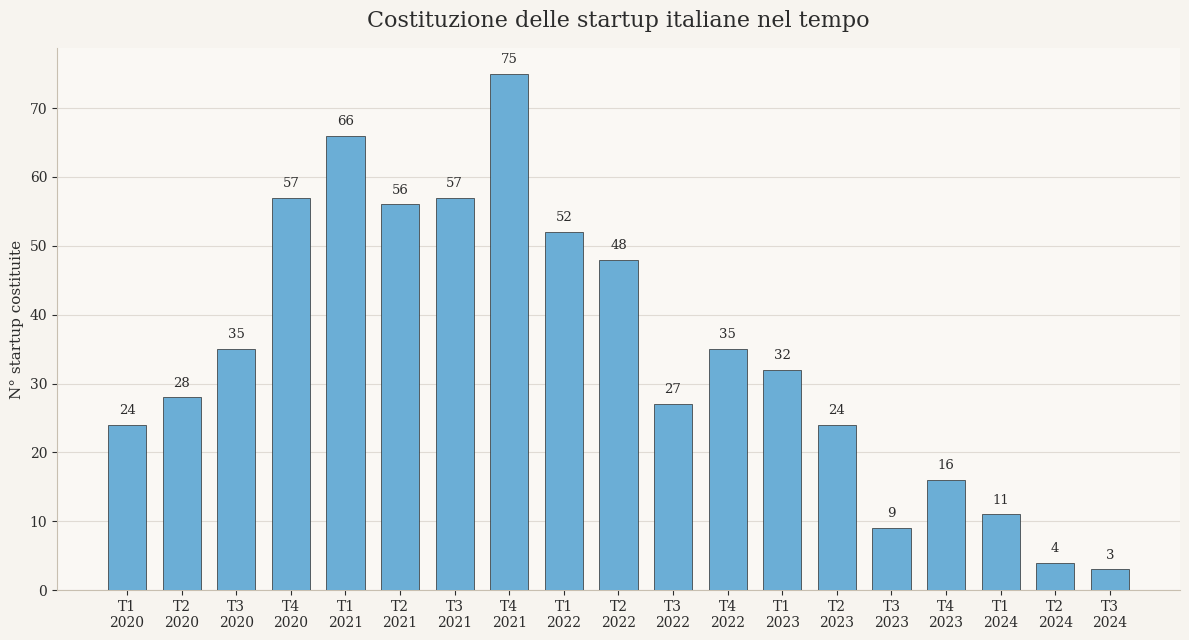

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# ── stile coerente con gli altri grafici ──
plt.rcParams['font.family'] = 'serif'

FIG_BG = '#f7f4ef'
AX_BG = '#faf8f4'
INK = '#2c2c2c'
GRID = '#e0dbd4'
SPINE = '#c8bfb0'

# un solo azzurrino per tutte le barre (preso dalla stessa rampa Blues)
COLORE_BARRE = '#6baed6'

# ── preparazione dati ──
df['data_costituzione'] = pd.to_datetime(df['data costituzione'], errors='coerce')
validi = df['data_costituzione'].notna()
print(f"Startup con data di costituzione valida: {validi.sum()} su {len(df)}")

serie = df.set_index('data_costituzione').resample('QS').size()
print(f"Periodo coperto: {serie.index.min():%m/%Y} – {serie.index.max():%m/%Y}")

# etichette tipo "T1 2020"
trimestri = [f"T{((d.month - 1) // 3) + 1}\n{d.year}" for d in serie.index]

# ── grafico ──
fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor(FIG_BG)
ax.set_facecolor(AX_BG)

barre = ax.bar(range(len(serie)), serie.values, color=COLORE_BARRE, width=0.7,
                edgecolor=INK, linewidth=0.5, zorder=3)

for i, v in enumerate(serie.values):
    ax.text(i, v + max(serie.values) * 0.015, str(v), ha='center', va='bottom',
             fontsize=9.5, color=INK)

ax.set_xticks(range(len(serie)))
ax.set_xticklabels(trimestri, fontsize=9)

ax.set_title("Costituzione delle startup italiane nel tempo", fontsize=16, color=INK, pad=15)
ax.set_ylabel("N° startup costituite", fontsize=11, color=INK)

ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(SPINE)

ax.tick_params(colors=INK, labelsize=10)

plt.tight_layout()

plt.savefig("costituzione_trimestrale.png", dpi=200, bbox_inches='tight', transparent=True)
plt.show()